Saving amazon.csv.zip to amazon.csv.zip
Files after extraction: ['.config', 'amazon.csv', 'amazon.csv.zip', 'sample_data']
Dataset Shape: (1465, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  revi

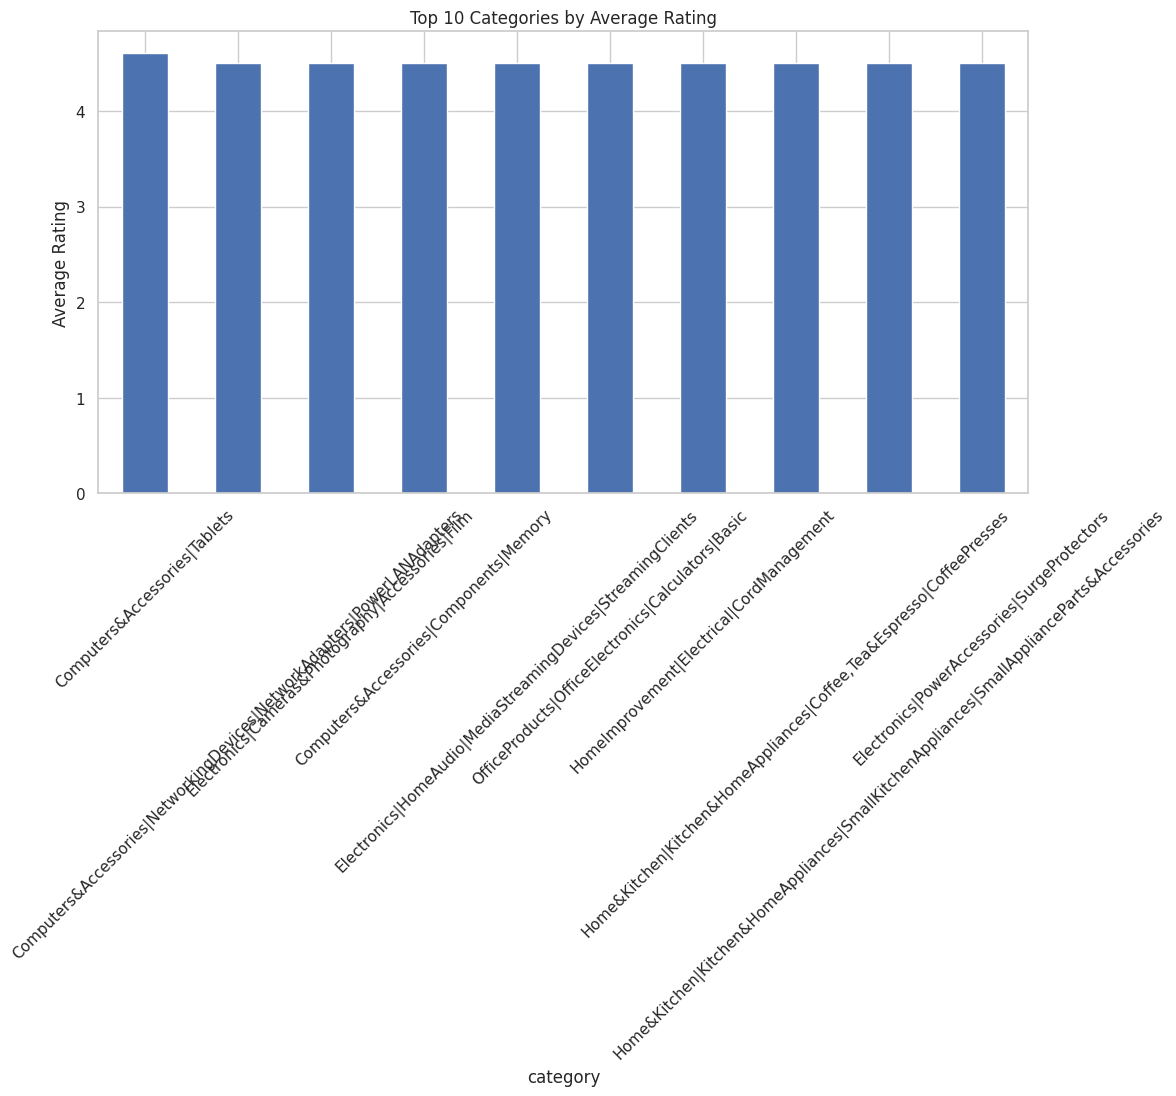

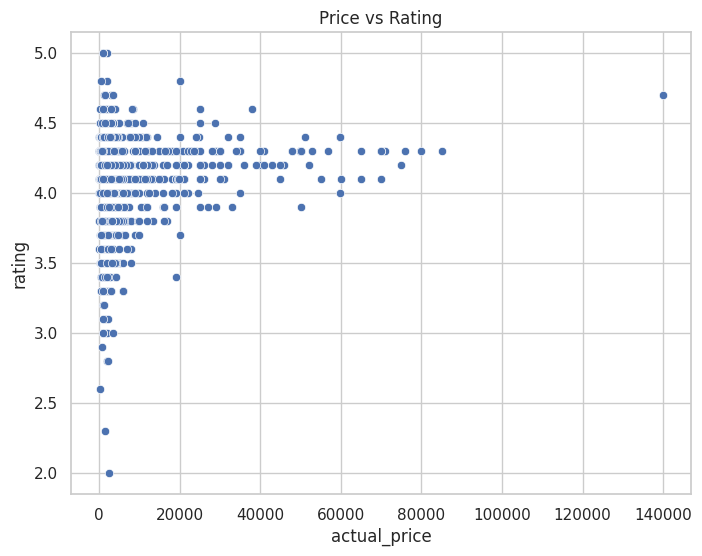

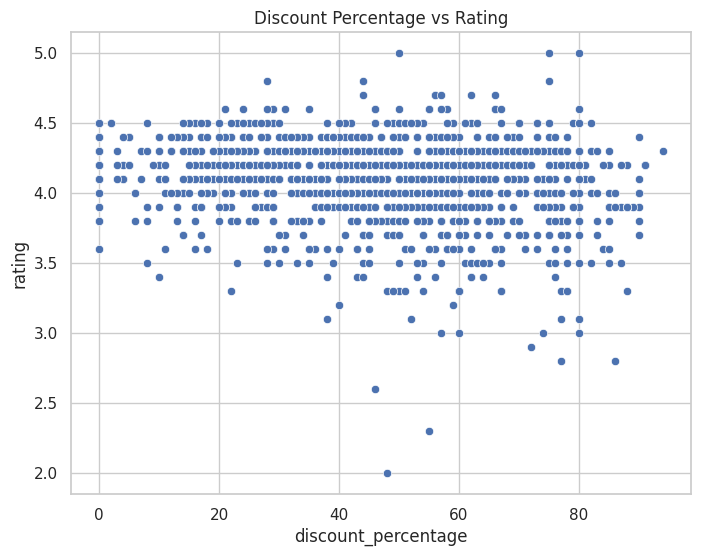

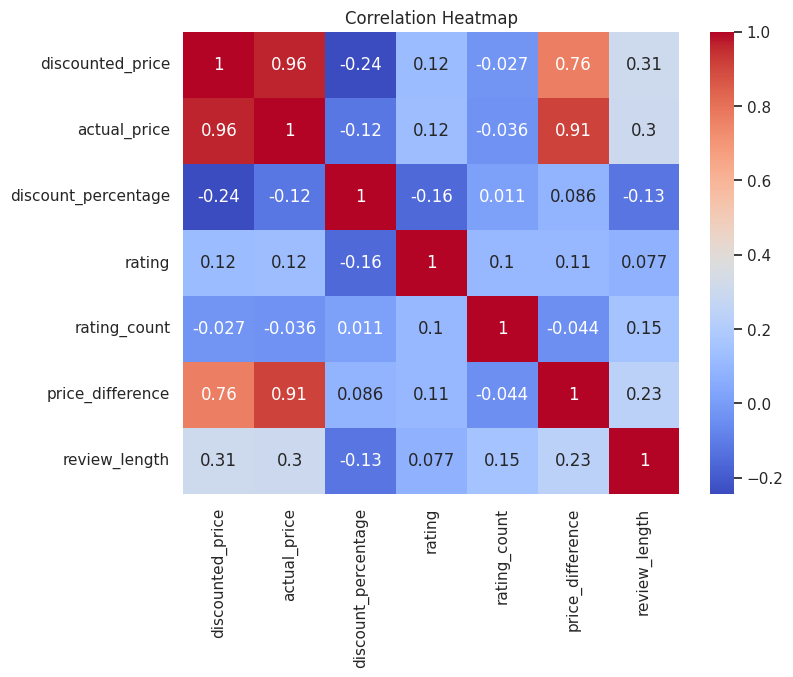

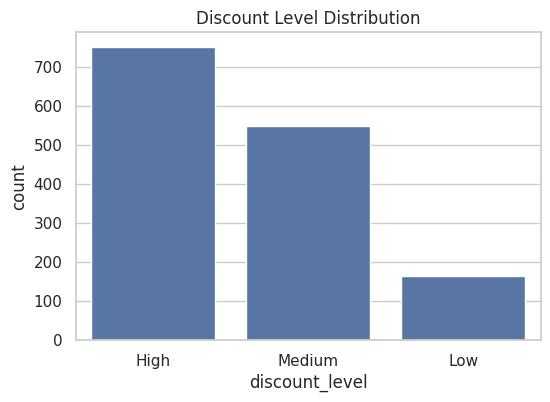

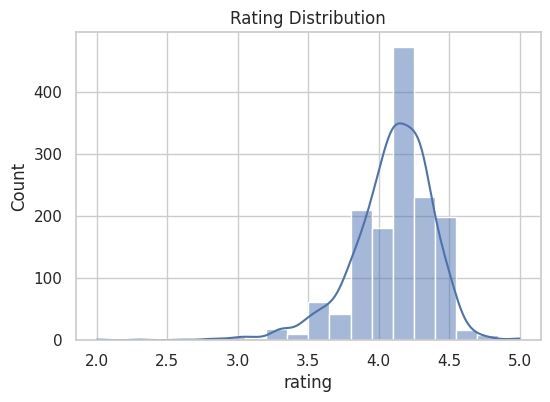

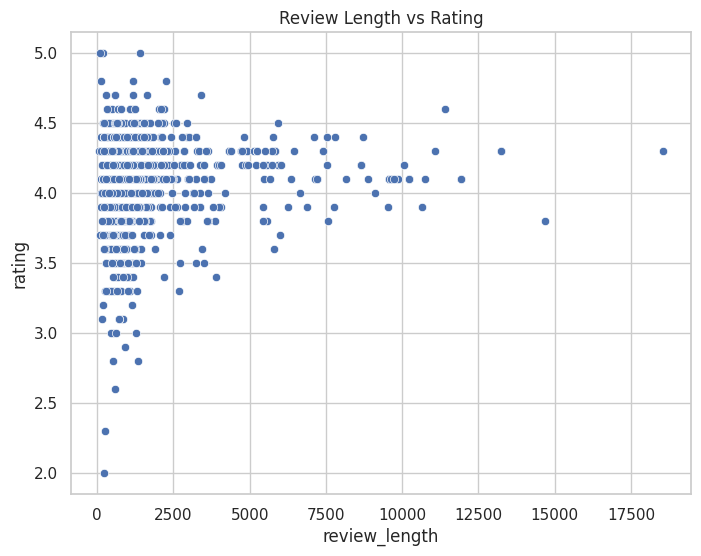

Average Rating: 4.096584699453552
Average Discount: 47.71311475409836
Total Reviews: 26765385.0
Total Products: 1350


In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os


sns.set(style="whitegrid")


#Upload ZIP File
from google.colab import files
uploaded = files.upload()


#Extract ZIP File
with zipfile.ZipFile("amazon.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()


print("Files after extraction:", os.listdir())


#Load Dataset
df = pd.read_csv("amazon.csv", encoding="utf-8")


print("Dataset Shape:", df.shape)
df.head()


#Basic Data Understanding
df.info()
df.describe()
df.isnull().sum()


#data cleaning
#Clean Price Columns
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)


df["actual_price"] = (
    df["actual_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)


df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce")
df["actual_price"] = pd.to_numeric(df["actual_price"], errors="coerce")


#Clean Discount Percentage
df["discount_percentage"] = (
    df["discount_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)


df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")
 #Clean Rating Count
df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)


df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")
#Convert Rating to Numeric
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
#Remove Duplicates
df = df.drop_duplicates()
#Drop Important Missing Values
df = df.dropna(subset=["rating", "discounted_price", "actual_price"])


#FEATURE ENGINEERING
#Price Difference
df["price_difference"] = df["actual_price"] - df["discounted_price"]
#Review Length
df["review_length"] = df["review_content"].astype(str).str.len()
#Discount Level Category
def discount_level(x):
    if x >= 50:
        return "High"
    elif x >= 20:
        return "Medium"
    else:
        return "Low"


df["discount_level"] = df["discount_percentage"].apply(discount_level)
#Rating Category
def rating_category(x):
    if x >= 4:
        return "Good"
    elif x >= 3:
        return "Average"
    else:
        return "Poor"


df["rating_category"] = df["rating"].apply(rating_category)


#EXPLORATORY DATA ANALYSIS (EDA)
# 1. Category Analysis
category_analysis = df.groupby("category").agg({
    "rating": "mean",
    "rating_count": "sum",
    "discount_percentage": "mean"
}).sort_values(by="rating", ascending=False)


category_analysis.head()
# Category vs Average Rating
plt.figure(figsize=(12,6))
category_analysis["rating"].head(10).plot(kind="bar")
plt.title("Top 10 Categories by Average Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()
#2. Price vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot(x="actual_price", y="rating", data=df)
plt.title("Price vs Rating")
plt.show()
#3. Discount vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot(x="discount_percentage", y="rating", data=df)
plt.title("Discount Percentage vs Rating")
plt.show()
# 4. Correlation Heatmap
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# 5. Top 10 Most Reviewed Products
top_reviewed = df.sort_values(by="rating_count", ascending=False).head(10)
top_reviewed[["product_name", "rating", "rating_count"]]
# 6. Top 10 Highest Rated Products
top_rated = df.sort_values(by="rating", ascending=False).head(10)
top_rated[["product_name", "rating", "rating_count"]]
#7. Discount Level Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="discount_level", data=df)
plt.title("Discount Level Distribution")
plt.show()
#8. Rating Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()
#9. Review Length vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot(x="review_length", y="rating", data=df)
plt.title("Review Length vs Rating")
plt.show()
#9 SUMMARY STATISTICS
print("Average Rating:", df["rating"].mean())
print("Average Discount:", df["discount_percentage"].mean())
print("Total Reviews:", df["rating_count"].sum())
print("Total Products:", df["product_id"].nunique())
